# Exploratory Data Analysis
**UCI Default of Credit Card Clients**

Goals:
- Understand the data shape, types, and quality
- Examine class balance
- Explore feature distributions and correlations
- Identify preprocessing needs
- Surface candidate predictive features

In [11]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 30)

In [12]:
from src.ingestion.load_data import load_raw
df = load_raw()
print(f'Shape: {df.shape}')
df.head()

2026-03-16 21:54:36 [INFO] src.ingestion.load_data: Loaded raw data: 30000 rows x 24 cols
Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 1. Basic info

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

In [14]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [15]:
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default_payment_next_month    0
dtype: int64

Duplicate rows: 35


## 2. Class balance

default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.12%


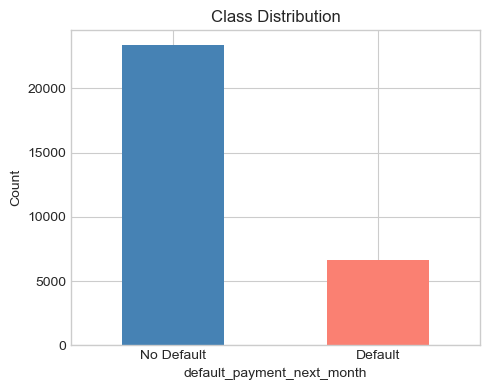

In [16]:
target = 'default_payment_next_month'
counts = df[target].value_counts()
print(counts)
print(f'\nDefault rate: {df[target].mean():.2%}')

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
ax.set_xticklabels(['No Default', 'Default'], rotation=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/class_balance.png', dpi=150)
plt.show()

## 3. Feature distributions

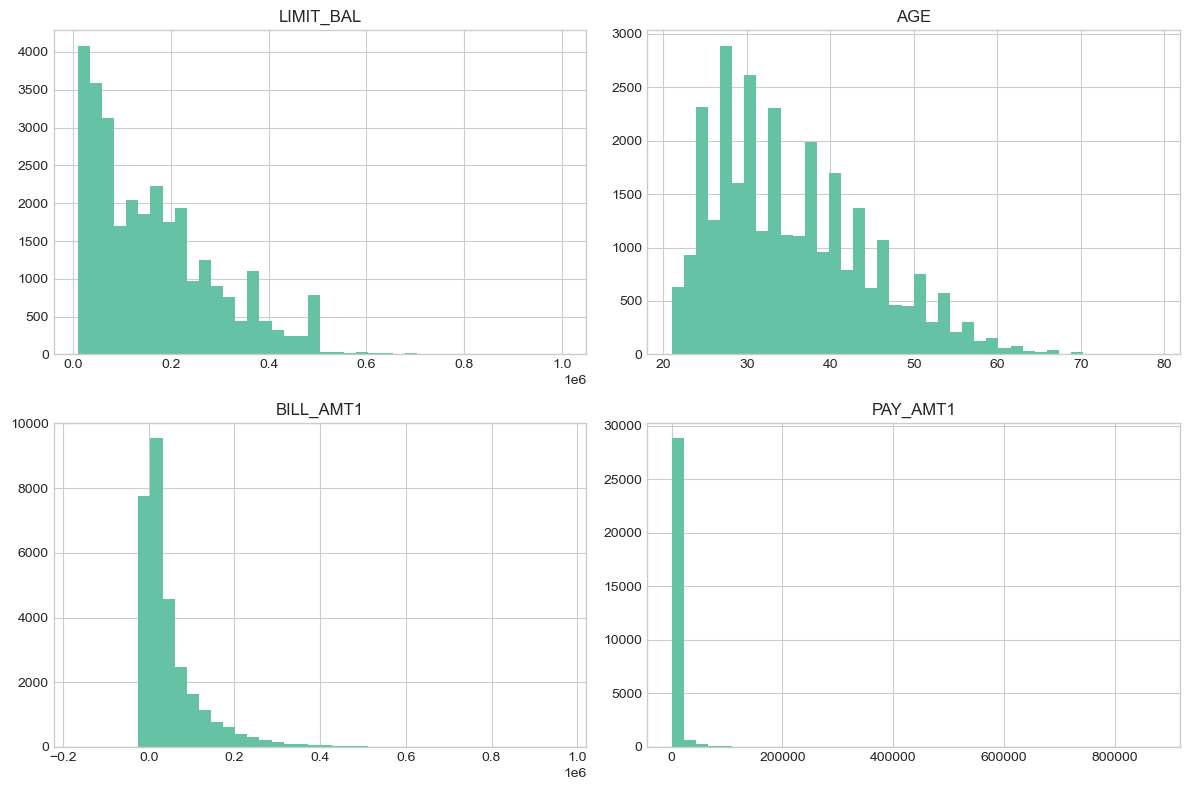

In [17]:
numeric_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, numeric_cols):
    df[col].hist(bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../reports/figures/feature_distributions.png', dpi=150)
plt.show()

## 4. Categorical features

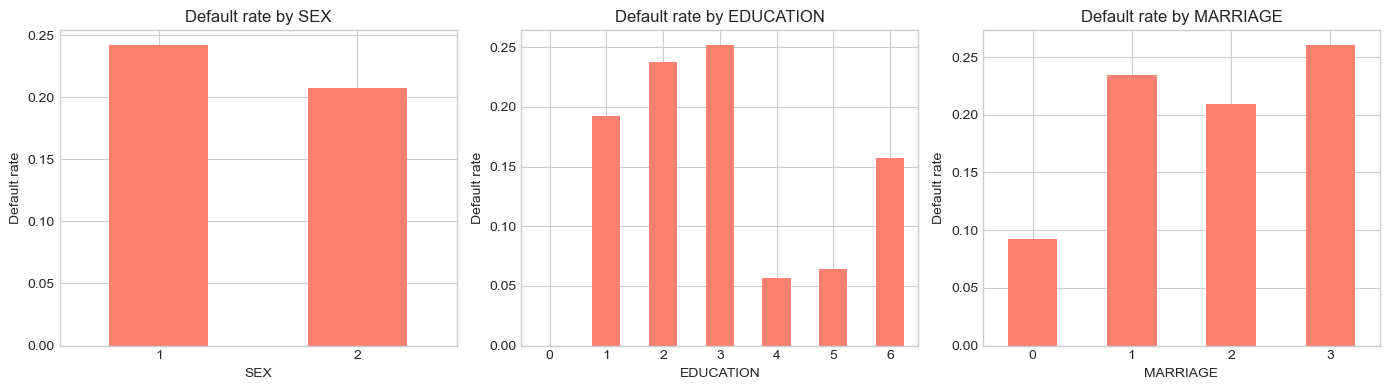

In [18]:
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    default_rate = df.groupby(col)[target].mean()
    default_rate.plot(kind='bar', ax=ax, color='salmon')
    ax.set_title(f'Default rate by {col}')
    ax.set_ylabel('Default rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/default_by_category.png', dpi=150)
plt.show()

## 5. Payment status vs default rate

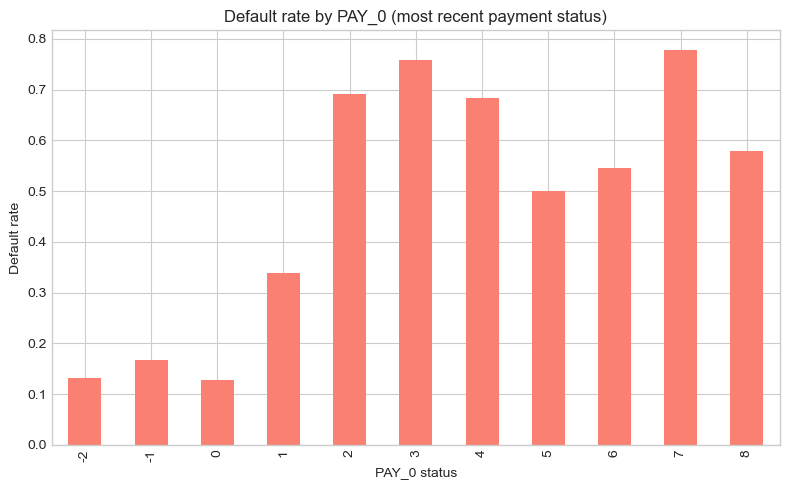

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
dr = df.groupby('PAY_0')[target].mean()
dr.plot(kind='bar', ax=ax, color='salmon')
ax.set_title('Default rate by PAY_0 (most recent payment status)')
ax.set_xlabel('PAY_0 status')
ax.set_ylabel('Default rate')
plt.tight_layout()
plt.show()

## 6. Correlation heatmap

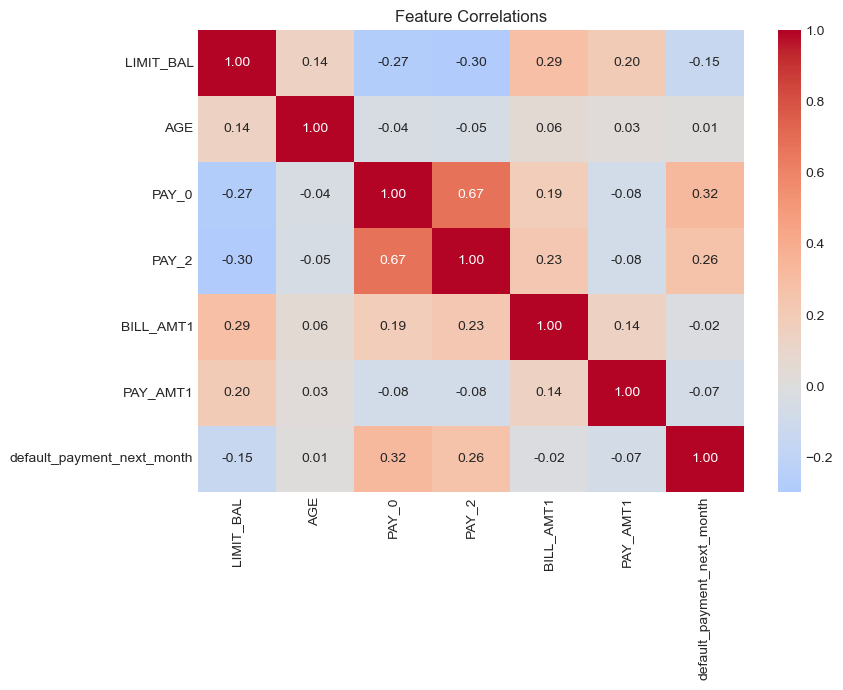

In [20]:
corr_cols = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1', target]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', ax=ax, cmap='coolwarm', center=0)
ax.set_title('Feature Correlations')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150)
plt.show()

## 7. Key observations

- **~22% default rate** -> significant class imbalance requiring `class_weight` or `scale_pos_weight`
- **PAY_0** has a strong monotonic relationship with default rate (most important feature)
- **LIMIT_BAL** is negatively correlated with default (higher limit -> lower default)
- **EDUCATION** and **MARRIAGE** show some variation but modest effect sizes
- BILL_AMT columns are highly correlated with each other -> derived trend features will be more informative
- No missing values in this dataset